In [1]:
from eib import *

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/shapely/creation.py:

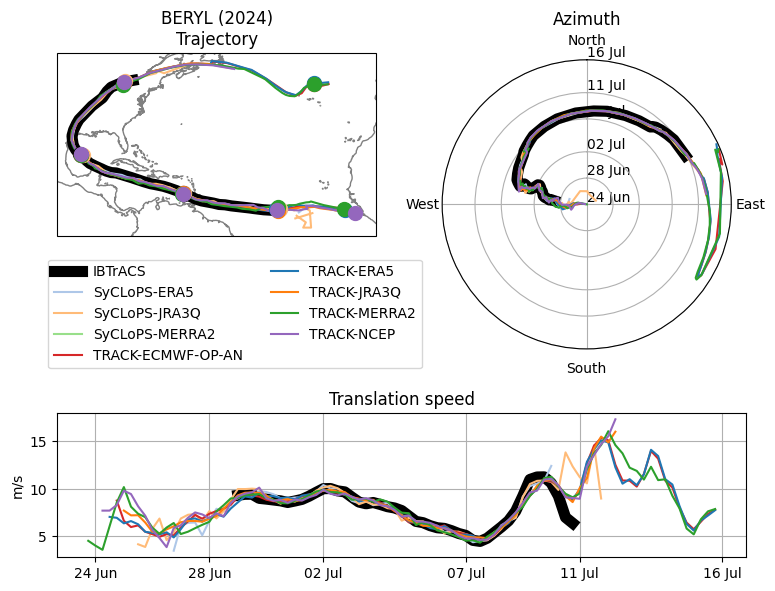

In [3]:
b = "NA"
eib = xr.open_dataset("../extended-ibtracs/extended-ibtracs_"+b+".nc")
TRACK = eib.where((eib.name == "BERYL") & (eib.time.dt.year == 2024), drop = True)
times = ["06-24", "06-28", "07-02", "07-07", "07-11", "07-16"]
times = [np.datetime64("2024-"+t) for t in times]
t_labels = [pd.Timestamp(d).strftime("%d %b") for d in times]

fig = plt.figure(figsize=(8, 6 ))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

# Top left: PlateCarree projection
ax_map = fig.add_subplot(gs[0, 0], projection=ccrs.Miller())
ax_map.coastlines(color = "gray")
ax_map.set_title("BERYL (2024)\nTrajectory")

# Top right: polar axes
ax_polar = fig.add_subplot(gs[0, 1], polar=True)
ax_polar.set_theta_zero_location("N")
ax_polar.set_theta_direction(-1)
ax_polar.set_rticks(times, t_labels)
ax_polar.set_rlabel_position(0)
ax_polar.set_title("Azimuth")
ax_polar.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2], ['North', 'East', "South", "West"])
ax_polar.set_rlim(times[0], times[-1])

# Bottom: regular axes spanning full width
ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.grid(axis = 'both')
ax_bottom.set_xticks(times, t_labels)
ax_bottom.set_title("Translation speed")
ax_bottom.set_ylabel("m/s")

for s in TRACK.source.values:
    T = TRACK.sel(source = s)
    lw = 8 if s == 'IBTrACS' else None
    ax_map.plot(T.lon, T.lat, transform = ccrs.PlateCarree(), 
                c = PALETTE[s], lw = lw, label=s)  # <-- add label here
    for t in times:
        pt = T.where(T.time == t,)
        ax_map.scatter(pt.lon, pt.lat, transform = ccrs.PlateCarree(), 
                c = PALETTE[s], s = 100, zorder = 100)
    ax_polar.plot(T.azimuth_roll * np.pi / 180, T.time, 
                  c = PALETTE[s], lw = lw,)
    ax_bottom.plot(T.time, T.translation_speed_roll, 
                   c = PALETTE[s], lw = lw,)

plt.tight_layout()

# Shift top row up a bit
for ax in [ax_map]:
    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + 0.1, box.width, box.height])

# Place legend between top and bottom rows
fig.legend(*ax_map.get_legend_handles_labels(),
           loc='center', bbox_to_anchor=(0.3, 0.47),
           ncol=2, frameon=True)

plt.savefig("azimuth_tspeed.png", bbox_inches="tight")